- Group Number - 113
- Name: Harsh Vijay Mamania
- NU ID: 002036770

# Fine-Tuning '**Mistral-7B-Instruct**' for Context-Based *Story Completion*

# 1. Setup and Configuration

## 1.1 Library Installation

In [2]:
# First install key libraries without forcing numpy/pandas changes
!pip install -q transformers==4.37.0 bitsandbytes==0.42.0 peft==0.7.0 accelerate==0.22.0
!pip install -q datasets==2.18.0 trl==0.8.1 sentencepiece==0.1.99
!pip install -q nltk==3.8.1 scikit-learn==1.4.0 rouge_score==0.1.2
!pip install triton==2.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.2/251.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## (Note: Restart session after this, so that these changes can apply to our run time)

## 1.2 Library and Module Imports

In [1]:
# Standard libraries
import os
import sys
import time
import warnings
import logging
import textwrap
import random
import unittest
from typing import Dict, List, Tuple, Any, Optional

# Data processing libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and tokenization
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.corpus import stopwords
from rouge_score import rouge_scorer

# Machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Hugging Face libraries
import torch
from datasets import Dataset
from huggingface_hub import login
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline
)
from peft import LoraConfig, get_peft_model, PeftModel, prepare_model_for_kbit_training
from tqdm.auto import tqdm
from trl import SFTTrainer

# Notebook display enhancements
from IPython.display import HTML, display

# GUI libraries
from IPython.display import display, clear_output, HTML
import ipywidgets as widgets
import torch
import textwrap

## 1.3 Notebook Display Setup

In [2]:
def set_css():
    """Configure IPython cell output for better readability with wrapped text."""
    display(HTML('''
    <style>
      pre {
          white-space: pre-wrap;
      }
    </style>
    '''))
get_ipython().events.register('pre_run_cell', set_css)

## 1.4 Utility Functions

In [3]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Set the seed for reproducibility
set_seed(42)

## 1.5 Suppress warnings to keep notebook clean

In [4]:
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

class WarningFilter:
    """Context manager to temporarily redirect stderr to suppress warnings."""
    def __enter__(self):
        self._original_stderr = sys.stderr
        sys.stderr = open(os.devnull, 'w')
        return self

    def __exit__(self, *args):
        sys.stderr.close()
        sys.stderr = self._original_stderr


## 1.5 Google Drive Integration

In [5]:
# Mount Google Drive for saving models
from google.colab import drive
drive.mount('/content/drive')

# Define paths for storing and loading models
DRIVE_BASE_MODEL_DIR = "/content/drive/MyDrive/NEU - MS CS/NLP/Project/models/base/mistral-7b"
DRIVE_FINE_TUNED_DIR = "/content/drive/MyDrive/NEU - MS CS/NLP/Project/models/fine_tuned/mistral-story-completion-pivot"
EVAL_OUTPUT_DIR = "/content/drive/MyDrive/NEU - MS CS/NLP/Project/evaluation_results/"
OUTPUT_DIR = "./mistral-story-completion-pivot"

# Create directories if they don't exist
os.makedirs(DRIVE_BASE_MODEL_DIR, exist_ok=True)
os.makedirs(DRIVE_FINE_TUNED_DIR, exist_ok=True)
os.makedirs(EVAL_OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


## 1.6 NLTK Setup

In [6]:
# Download NLTK data for BLEU score calculation and stratification
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 1.7 Configuration Parameters

In [ ]:
# Configuration parameters
class Config:
    """Configuration class to store all parameters for the project."""
    # General
    PIVOT_TEST = True  # Set to False for full training
    MAX_SAMPLES = 500  # Maximum samples for pivot test
    FORCE_RETRAINING = True  # Set to True to force retraining even if a model exists
    HF_TOKEN = "..."  # Your Hugging Face token
    MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

    # Data splitting
    TEST_SPLIT_PERCENTAGE = 0.10  # 15% for validation

    # LoRA parameters
    LORA_RANK = 8          # Rank dimension (r) - balance between capacity and efficiency
    LORA_ALPHA = 16        # Alpha scaling parameter - typically 2x rank
    TARGET_MODULES = ["q_proj", "v_proj", "k_proj", "o_proj"]  # Target modules for LoRA adaptation

    # Training parameters
    EPOCHS = 2 if PIVOT_TEST else 3             # Number of training epochs
    BATCH_SIZE = 1                              # Per-device batch size
    GRADIENT_ACCUMULATION = 4 if PIVOT_TEST else 8  # Gradient accumulation steps
    MAX_STEPS = 100 if PIVOT_TEST else None     # Maximum training steps (None=unlimited)
    LEARNING_RATE = 2e-4
    WEIGHT_DECAY = 0.01

    # Evaluation
    EVAL_PERCENTAGE = 100  # Percentage of validation set to evaluate

    # Generation parameters
    MAX_NEW_TOKENS = 150
    TEMPERATURE = 0.7
    TOP_P = 0.9
    REPETITION_PENALTY = 1.2

    # Default story context
    DEFAULT_CONTEXT = """
    In the small coastal town of Millfield, strange lights had been appearing in the night sky for weeks.
    The local observatory was overwhelmed with calls, and the town's usually quiet streets were now filled
    with amateur astronomers and curious onlookers. Dr. Eleanor Hayes, the town's only astronomer, had
    been working tirelessly to understand the phenomenon, but her equipment was limited and outdated.
    """

config = Config()

---

# 2. Data Processing

## 2.1 Data Loading

In [8]:
def load_dataset(file_path: str, limit_samples: bool = True, max_samples: int = 200) -> pd.DataFrame:
    """Load and optionally limit the dataset size for faster experimentation.

    Args:
        file_path: Path to the CSV file containing the dataset
        limit_samples: Whether to limit the number of samples
        max_samples: Maximum number of samples if limiting

    Returns:
        DataFrame containing the dataset (potentially limited)
    """
    print(f"Loading dataset from {file_path}...")
    df = pd.read_csv(file_path)
    print(f"Total dataset size: {len(df)}")

    if limit_samples and len(df) > max_samples:
        df = df.sample(max_samples, random_state=42).reset_index(drop=True)
        print(f"Reduced dataset to {len(df)} samples for pivot test")

    return df

(Note: Before running the cell below, please upload the dataset to your current Google Collab run time)

In [9]:
# Load the dataset with optional size limiting
df = load_dataset("better_processed_data2.0.csv",
                 limit_samples=config.PIVOT_TEST,
                 max_samples=config.MAX_SAMPLES)

Loading dataset from better_processed_data2.0.csv...
Total dataset size: 7749
Reduced dataset to 500 samples for pivot test


In [10]:
df.head()

,Unnamed: 0,context,input,output
0,1720,OUVRAGES DU MME AUTEUR DES VERS. LA MAISON TEL...,LES CONTES DE LA BCASSE.,LES CONTES DE LA BCASSE. CLAIR DE LUNE. AU SOL...
1,1163,"Jimmy watches the Natchez Belle draw near, a s...","One day, Pigtail Anne sees the news","One day, Pigtail Anne sees the news item on th..."
2,3592,The Queen decides upon two people to bring to ...,They drink from the water until they,They drink from the water until they sink into...
3,5407,It was too true that the city was growing rapi...,Then she threw it back into the,Then she threw it back into the trashcan and b...
4,132,"Mr. Hutton finds Janet Spence in the room, sta...",He is amused by the photographs of,He is amused by the photographs of Lady of Chr...


## 2.2 Content-Based Stratification

In [11]:
def stratify_by_content(df: pd.DataFrame) -> pd.DataFrame:
    """Implement content-based stratification using text clustering.

    This function:
    1. Combines context and input text
    2. Creates TF-IDF vectors for text data
    3. Applies KMeans clustering to identify themes
    4. Samples proportionally from each cluster using square root scaling

    Args:
        df: DataFrame containing 'context' and 'input' columns

    Returns:
        DataFrame with balanced samples across different themes
    """
    print("Implementing content-based stratification...")

    # Prepare text for thematic analysis (combine context and input)
    df['combined_text'] = df['context'].fillna('') + " " + df['input'].fillna('')

    # Create TF-IDF vectorizer to convert text to numerical features
    vectorizer = TfidfVectorizer(
        max_features=1000,  # Limit features to top 1000 terms
        min_df=2,           # Terms must appear in at least 2 documents (reduced for small dataset)
        max_df=0.8,         # Ignore terms that appear in >80% of documents
        stop_words=stopwords.words('english')  # Remove common words
    )

    # Create document vectors
    tfidf_matrix = vectorizer.fit_transform(df['combined_text'])

    # Determine number of clusters (themes) - adaptive based on dataset size
    n_clusters = min(5, max(2, int(len(df) * 0.05)))
    print(f"Using {n_clusters} thematic clusters")

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['theme_cluster'] = kmeans.fit_predict(tfidf_matrix)

    # Print top terms per cluster to understand the themes
    feature_names = vectorizer.get_feature_names_out()
    centroids = kmeans.cluster_centers_
    print("\nTop terms per cluster:")
    for i in range(n_clusters):
        indices = centroids[i].argsort()[::-1]
        top_features = [feature_names[j] for j in indices[:10]]
        print(f"Cluster {i}: {', '.join(top_features)}")

    # Print distribution of samples across clusters
    print("\nDistribution of samples by theme cluster:")
    cluster_counts = df['theme_cluster'].value_counts()
    print(cluster_counts)
    print(f"Total input samples: {len(df)}")

    # Visualize cluster distribution
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x='theme_cluster', data=df, palette='viridis')
    plt.title('Distribution of Samples Across Theme Clusters')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Samples')

    # Add count labels above bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'bottom')
    plt.show()

    # Balanced sampling - using a square root scaling approach
    # This gives more representation to smaller clusters while not overwhelming with large clusters
    sample_df = pd.DataFrame()

    # Calculate sqrt of counts to get a more balanced distribution
    sqrt_counts = np.sqrt(cluster_counts)
    # Normalize to sum to the total desired sample count
    scaling_factor = len(df) / sqrt_counts.sum()
    sqrt_scaled_counts = (sqrt_counts * scaling_factor).astype(int)

    # Ensure each cluster has at least 1 sample
    sqrt_scaled_counts = sqrt_scaled_counts.clip(lower=1)

    print("\nSamples selected from each cluster using square root scaling:")
    print("Formula used: n_samples = sqrt(cluster_size) * scaling_factor")
    print(f"Scaling factor: {scaling_factor:.2f}")

    # Select samples from each cluster
    for cluster, scaled_count in sqrt_scaled_counts.items():
        cluster_df = df[df['theme_cluster'] == cluster]

        # Make sure we don't try to sample more than available
        actual_count = min(scaled_count, len(cluster_df))
        cluster_sample = cluster_df.sample(n=actual_count, random_state=42)
        sample_df = pd.concat([sample_df, cluster_sample])
        print(f"Cluster {cluster}: {actual_count} samples from {len(cluster_df)} available ({actual_count/len(cluster_df)*100:.1f}%)")

    print(f"\nTotal samples after stratification: {len(sample_df)}")
    print("Final distribution in stratified sample:")
    print(sample_df['theme_cluster'].value_counts())

    # Visualize before/after distribution
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    original_counts = df['theme_cluster'].value_counts().sort_index()
    bars1 = plt.bar(original_counts.index, original_counts.values, color='skyblue')
    plt.title('Original Distribution')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Samples')

    # Add count labels above bars for original distribution
    for bar in bars1:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom')

    plt.subplot(1, 2, 2)
    stratified_counts = sample_df['theme_cluster'].value_counts().sort_index()
    bars2 = plt.bar(stratified_counts.index, stratified_counts.values, color='salmon')
    plt.title('Stratified Distribution')
    plt.xlabel('Cluster ID')
    plt.ylabel('Number of Samples')

    # Add count labels above bars for stratified distribution
    for bar in bars2:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return sample_df.reset_index(drop=True)

Implementing content-based stratification...
Using 5 thematic clusters

Top terms per cluster:
Cluster 0: uncover, extensive, evidence, research, copyright, renewed, publication, science, etext, produced
Cluster 1: old, house, mr, years, narrator, lives, mary, one, man, father
Cluster 2: man, tells, one, two, back, time, explains, like, find, go
Cluster 3: day, called, mrs, la, william, robert, world, make, woman, caswell
Cluster 4: stories, story, volume, book, new, chapter, author, english, first, published

Distribution of samples by theme cluster:
theme_cluster
2    183
3    124
1     90
4     73
0     30
Name: count, dtype: int64
Total input samples: 500


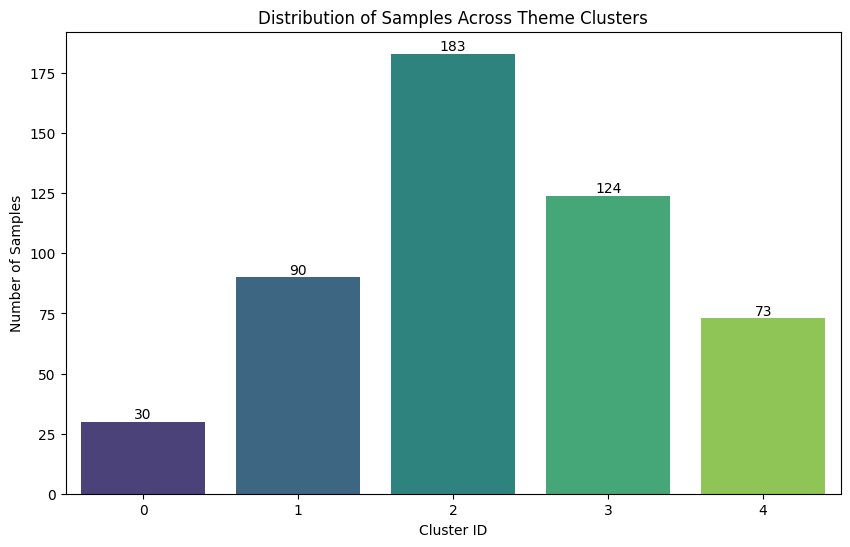


Samples selected from each cluster using square root scaling:
Formula used: n_samples = sqrt(cluster_size) * scaling_factor
Scaling factor: 10.38
Cluster 2: 140 samples from 183 available (76.5%)
Cluster 3: 115 samples from 124 available (92.7%)
Cluster 1: 90 samples from 90 available (100.0%)
Cluster 4: 73 samples from 73 available (100.0%)
Cluster 0: 30 samples from 30 available (100.0%)

Total samples after stratification: 448
Final distribution in stratified sample:
theme_cluster
2    140
3    115
1     90
4     73
0     30
Name: count, dtype: int64


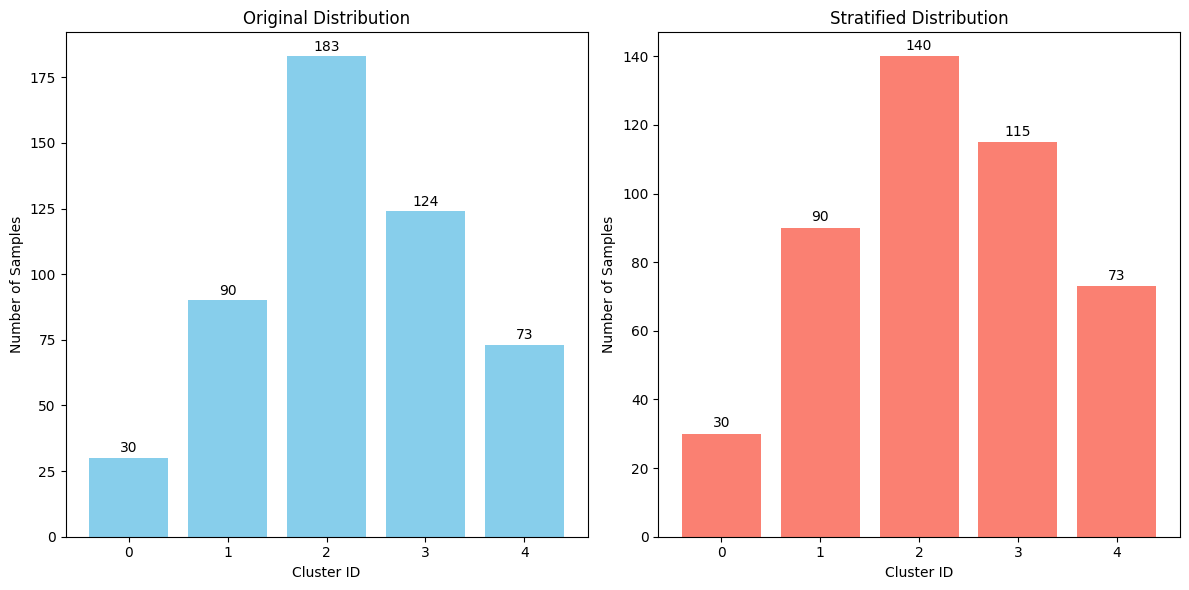

In [12]:
# Apply stratification
sample_df = stratify_by_content(df)

## 2.3 Unit Tests for Stratification

In [13]:
class StratificationTests(unittest.TestCase):
    """Unit tests for the content-based stratification function."""

    def test_stratified_sample_size(self):
        """Test that stratification doesn't dramatically reduce dataset size."""
        # Create a simple test DataFrame
        test_df = pd.DataFrame({
            'context': ['A'] * 50 + ['B'] * 30 + ['C'] * 20,
            'input': ['X'] * 100
        })

        # Apply stratification with a mocked vectorizer
        test_df['combined_text'] = test_df['context'] + ' ' + test_df['input']
        test_df['theme_cluster'] = [0] * 50 + [1] * 30 + [2] * 20

        # Calculate expected counts based on square root scaling
        counts = test_df['theme_cluster'].value_counts()
        sqrt_counts = np.sqrt(counts)
        scaling_factor = len(test_df) / sqrt_counts.sum()
        expected_counts = (sqrt_counts * scaling_factor).astype(int).clip(lower=1)
        expected_total = expected_counts.sum()

        # Check that we don't lose more than 20% of samples through stratification
        self.assertGreaterEqual(expected_total, len(test_df) * 0.8,
                               "Stratification should not reduce dataset size by more than 20%")

    def test_all_clusters_represented(self):
        """Test that all clusters are represented in stratified data."""
        # Create a simple test DataFrame with very imbalanced clusters
        test_df = pd.DataFrame({
            'context': ['A'] * 90 + ['B'] * 8 + ['C'] * 2,
            'input': ['X'] * 100
        })

        # Apply stratification with a mocked vectorizer
        test_df['combined_text'] = test_df['context'] + ' ' + test_df['input']
        test_df['theme_cluster'] = [0] * 90 + [1] * 8 + [2] * 2

        # Calculate square root scaled counts
        counts = test_df['theme_cluster'].value_counts()
        sqrt_counts = np.sqrt(counts)
        scaling_factor = len(test_df) / sqrt_counts.sum()
        expected_counts = (sqrt_counts * scaling_factor).astype(int).clip(lower=1)

        # Verify even the smallest cluster has at least one sample
        self.assertTrue(all(expected_counts >= 1),
                        "All clusters should have at least one sample in stratified data")

In [14]:
# Run the stratification tests
unittest.TextTestRunner().run(unittest.TestLoader().loadTestsFromTestCase(StratificationTests))

..
----------------------------------------------------------------------
Ran 2 tests in 0.009s

OK


<unittest.runner.TextTestResult run=2 errors=0 failures=0>

## 2.4 Prompt Formatting

In [15]:
def format_prompt(row: Dict[str, str]) -> Dict[str, str]:
    """Format a data row into a structured prompt for instruction tuning.

    Args:
        row: Dictionary containing 'context', 'input', and 'output' keys

    Returns:
        Dictionary with 'prompt', 'target', and 'formatted_text' keys
    """
    prompt = f"""<s>[INST] Continue this story concisely (1 paragraph):
Context: {row['context']}
Input: {row['input']} [/INST]"""

    target = row['output']
    return {
        "prompt": prompt,
        "target": target,
        "formatted_text": f"{prompt} {target}</s>"
    }

In [16]:
def prepare_dataset(df: pd.DataFrame, test_split: float = 0.1) -> Tuple[Dataset, Dataset]:
    """Prepare and split the dataset for training.

    Args:
        df: DataFrame with the data
        test_split: Fraction of data to use for validation

    Returns:
        Tuple of (train_dataset, valid_dataset)
    """
    # Apply the formatting to create a new dataset
    formatted_data = [format_prompt(row) for _, row in df.iterrows()]

    # Convert to HuggingFace Dataset format
    dataset = Dataset.from_pandas(pd.DataFrame(formatted_data))

    # Split into train and validation sets
    dataset = dataset.train_test_split(test_size=test_split, seed=42)
    train_dataset = dataset['train']
    valid_dataset = dataset['test']

    print(f"Training examples: {len(train_dataset)} ({(1-test_split)*100:.1f}% of dataset)")
    print(f"Validation examples: {len(valid_dataset)} ({test_split*100:.1f}% of dataset)")

    return train_dataset, valid_dataset

In [17]:
# Prepare the dataset
train_dataset, valid_dataset = prepare_dataset(sample_df, test_split=config.TEST_SPLIT_PERCENTAGE)

Training examples: 403 (90.0% of dataset)
Validation examples: 45 (10.0% of dataset)


In [18]:
# Preview a sample
print("\nSample formatted example:")
print(train_dataset[0]['formatted_text'])


Sample formatted example:
<s>[INST] Continue this story concisely (1 paragraph):
Context: Thomas Gilchrist, the chief physical chemist at Triton, visits Alemn and Catherine Bardas in the lab to check on their progress. He has a thermometer with an air thermometer attached to it, which he uses to make calculations. 
Input: Catherine asks him how his work is [/INST] Catherine asks him how his work is going. She wants to know if there's anything she can do to help them colonize the moon. Alemn tells her that they're trying to find a way to use low-temperature hydrogen to make life on the moon easier for people who don't like cold weather. Catherine goes off to talk to some other scientists about her work.</s>


## 2.5 Unit Tests for Prompt Formatting

In [19]:
class FormatPromptTests(unittest.TestCase):
    """Unit tests for prompt formatting functionality."""

    def test_prompt_structure(self):
        """Test that the prompt is correctly structured with instruction tags."""
        sample_row = {
            'context': 'Test context.',
            'input': 'Test input.',
            'output': 'Test output.'
        }
        formatted = format_prompt(sample_row)

        # Check instruction tags
        self.assertTrue('<s>[INST]' in formatted['prompt'], "Prompt should start with <s>[INST]")
        self.assertTrue('[/INST]' in formatted['prompt'], "Prompt should end with [/INST]")

        # Check content presence
        self.assertTrue('Context: Test context.' in formatted['prompt'], "Context should be included")
        self.assertTrue('Input: Test input.' in formatted['prompt'], "Input should be included")

        # Check target is preserved
        self.assertEqual(formatted['target'], 'Test output.')

        # Check formatted_text structure
        expected_start = formatted['prompt']
        expected_end = 'Test output.</s>'
        self.assertTrue(formatted['formatted_text'].startswith(expected_start),
                        "formatted_text should start with the prompt")
        self.assertTrue(formatted['formatted_text'].endswith(expected_end),
                        "formatted_text should end with target and </s>")

    def test_handles_missing_context(self):
        """Test that the formatter handles missing context gracefully."""
        sample_row = {
            'context': None,
            'input': 'Test input.',
            'output': 'Test output.'
        }
        formatted = format_prompt(sample_row)

        # Check that None is handled without errors
        self.assertTrue('Context: None' in formatted['prompt'] or 'Context: ' in formatted['prompt'],
                       "Should handle None context gracefully")

In [20]:
# Run the formatting tests
unittest.TextTestRunner().run(unittest.TestLoader().loadTestsFromTestCase(FormatPromptTests))

..
----------------------------------------------------------------------
Ran 2 tests in 0.002s

OK


<unittest.runner.TextTestResult run=2 errors=0 failures=0>

---

# 3. Model Setup

## 3.1 Hugging Face Authentication

In [21]:
def authenticate_huggingface(token: str) -> None:
    """Authenticate with the Hugging Face Hub.

    Args:
        token: Hugging Face authentication token
    """
    login(token=token)
    print("Authenticated with Hugging Face Hub")

In [22]:
# Authenticate with Hugging Face
authenticate_huggingface(config.HF_TOKEN)

Authenticated with Hugging Face Hub


## 3.2 Load Base Model

In [23]:
def load_base_model(model_name: str, drive_model_dir: str) -> Tuple[AutoModelForCausalLM, AutoTokenizer]:
    """Load the base model, either from Google Drive or Hugging Face.

    Args:
        model_name: Name of the model on Hugging Face
        drive_model_dir: Directory to save/load model on Google Drive

    Returns:
        Tuple of (model, tokenizer)
    """
    # Configure BitsAndBytes for 4-bit quantization
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    print("\nChecking for base model in Google Drive...")
    try:
        if os.path.exists(drive_model_dir):
            print(f"Base model found at {drive_model_dir}")
            # Load the tokenizer from Drive
            tokenizer = AutoTokenizer.from_pretrained(
                drive_model_dir,
                trust_remote_code=True,
                use_fast=False
            )
            tokenizer.pad_token = tokenizer.eos_token

            # Load the model from Drive
            model = AutoModelForCausalLM.from_pretrained(
                drive_model_dir,
                quantization_config=bnb_config,
                device_map="auto",
                trust_remote_code=True,
            )
            print("Base model and tokenizer loaded from Drive successfully!")
        else:
            # Load from Hugging Face
            print(f"Base model not found on Drive. Downloading from Hugging Face...")

            # Load the base tokenizer and model
            tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False)
            tokenizer.pad_token = tokenizer.eos_token

            # Ensure the model is loaded with 4-bit quantization
            model = AutoModelForCausalLM.from_pretrained(
                model_name,
                quantization_config=bnb_config,
                device_map="auto",
                trust_remote_code=True,
            )

            # Save base model to Drive for future use
            print(f"Saving base model to Drive at {drive_model_dir}...")
            os.makedirs(drive_model_dir, exist_ok=True)
            model.save_pretrained(drive_model_dir)
            tokenizer.save_pretrained(drive_model_dir)
            print("Base model saved to Drive!")
    except Exception as e:
        print(f"Error loading model: {e}")
        print("Loading base model directly from Hugging Face...")

        # Load the base tokenizer and model directly
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True, use_fast=False)
        tokenizer.pad_token = tokenizer.eos_token

        # Ensure the model is loaded with 4-bit quantization
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )

    # Enable gradient checkpointing to save memory
    model.gradient_checkpointing_enable()
    model = prepare_model_for_kbit_training(model)

    return model, tokenizer

In [24]:
# Load the base model
model, tokenizer = load_base_model(config.MODEL_NAME, DRIVE_BASE_MODEL_DIR)


Checking for base model in Google Drive...
Base model found at /content/drive/MyDrive/NEU - MS CS/NLP/Project/models/base/mistral-7b
Error loading model: /content/drive/MyDrive/NEU - MS CS/NLP/Project/models/base/mistral-7b does not appear to have a file named config.json. Checkout 'https://huggingface.co//content/drive/MyDrive/NEU - MS CS/NLP/Project/models/base/mistral-7b/None' for available files.
Loading base model directly from Hugging Face...


tokenizer_config.json:   0%|          | 0.00/2.10k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

## 3.3 Hardware Check

In [25]:
def check_gpu():
    """Check and display GPU availability and specifications."""
    print("CUDA Available:", torch.cuda.is_available())
    print("CUDA Device Count:", torch.cuda.device_count())
    if torch.cuda.is_available():
        print("CUDA Device Name:", torch.cuda.get_device_name(0))

In [26]:
# Verify that GPU is available
check_gpu()

CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: Tesla T4


## 3.4 QLoRA Configuration

In [27]:
def configure_lora(model: AutoModelForCausalLM,
                   rank: int = 8,
                   alpha: int = 16,
                   target_modules: List[str] = None) -> Tuple[AutoModelForCausalLM, LoraConfig]:
    """Configure and apply LoRA to the model.

    Args:
        model: Base model to apply LoRA to
        rank: LoRA rank dimension (r) - balance between capacity and efficiency
        alpha: LoRA alpha scaling parameter - typically 2x rank
        target_modules: List of module names to apply LoRA to

    Returns:
        Tuple of (model with LoRA, LoRA config)
    """
    if target_modules is None:
        target_modules = ["q_proj", "v_proj", "k_proj", "o_proj"]

    # LoRA configuration - balanced approach
    peft_config = LoraConfig(
        r=rank,                     # Rank dimension
        lora_alpha=alpha,           # Scale parameter
        target_modules=target_modules,   # Target key modules
        lora_dropout=0.1,                # Dropout for regularization
        bias="none",                     # Don't apply LoRA to biases
        task_type="CAUSAL_LM",           # For causal language modeling
    )

    # Apply LoRA config to the model
    model = get_peft_model(model, peft_config)
    print("LoRA parameters added to model")

    # Display trainable vs non-trainable parameters
    model.print_trainable_parameters()

    return model, peft_config

# Configure LoRA for the model
model, peft_config = configure_lora(
    model,
    rank=config.LORA_RANK,
    alpha=config.LORA_ALPHA,
    target_modules=config.TARGET_MODULES
)

LoRA parameters added to model
trainable params: 6,815,744 || all params: 7,248,547,840 || trainable%: 0.0940290959023318


---

# 4. Model Training

## 4.1 Training Configuration

In [28]:
def configure_training_args(output_dir: str, config_obj: Any) -> TrainingArguments:
    """Configure training arguments based on whether it's a pivot test or full training.

    Args:
        output_dir: Directory to save model outputs
        config_obj: Configuration object with training parameters

    Returns:
        TrainingArguments object
    """
    if config_obj.PIVOT_TEST:
        # Training arguments optimized for quick pivot test
        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=config_obj.EPOCHS,
            per_device_train_batch_size=config_obj.BATCH_SIZE,
            gradient_accumulation_steps=config_obj.GRADIENT_ACCUMULATION,
            save_steps=len(train_dataset),  # Save once at the end of training
            logging_steps=10,               # Log frequently to monitor
            learning_rate=config_obj.LEARNING_RATE,
            weight_decay=config_obj.WEIGHT_DECAY,
            warmup_ratio=0.03,
            lr_scheduler_type="cosine",     # Cosine annealing schedule
            optim="adamw_torch",
            fp16=True,                     # Mixed precision training
            evaluation_strategy="steps",   # Evaluate during training
            eval_steps=len(train_dataset), # Evaluate once at the end
            save_total_limit=1,            # Only keep 1 checkpoint to save space
            push_to_hub=False,
            load_best_model_at_end=True,
            report_to="none",              # To avoid wandb or other trackers
            max_steps=config_obj.MAX_STEPS,           # Limit total steps for pivot test
        )
    else:
        # Full training configuration
        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=config_obj.EPOCHS,
            per_device_train_batch_size=config_obj.BATCH_SIZE,
            gradient_accumulation_steps=config_obj.GRADIENT_ACCUMULATION,
            save_steps=100,
            logging_steps=20,
            learning_rate=config_obj.LEARNING_RATE,
            weight_decay=config_obj.WEIGHT_DECAY,
            warmup_ratio=0.03,
            lr_scheduler_type="cosine",
            optim="adamw_torch",
            fp16=True,
            evaluation_strategy="steps",
            eval_steps=100,
            save_total_limit=2,
            push_to_hub=False,
            load_best_model_at_end=True,
            report_to="none",
            max_steps=config_obj.MAX_STEPS,
        )
    return training_args

## 4.2 Trainer Setup

In [29]:
def create_trainer(model: AutoModelForCausalLM,
                   tokenizer: AutoTokenizer,
                   train_dataset: Dataset,
                   valid_dataset: Dataset,
                   peft_config: LoraConfig,
                   training_args: TrainingArguments) -> SFTTrainer:
    """Create and initialize the SFT Trainer.

    Args:
        model: Model to fine-tune
        tokenizer: Tokenizer to use
        train_dataset: Training dataset
        valid_dataset: Validation dataset
        peft_config: LoRA configuration
        training_args: Training arguments

    Returns:
        Initialized SFTTrainer
    """
    # Tokenize the datasets
    print("\nTokenizing datasets...")
    def tokenize_function(examples):
        # Tokenize the formatted text
        result = tokenizer(examples["formatted_text"], truncation=True, max_length=512)
        return result

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_valid = valid_dataset.map(tokenize_function, batched=True)

    # Initialize the SFT Trainer
    trainer = SFTTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_valid,
        tokenizer=tokenizer,
        peft_config=peft_config,
        dataset_text_field="formatted_text",
        max_seq_length=512,
    )

    return trainer

## 4.3 Fine-tuning Process

In [30]:
def fine_tune_model(trainer: SFTTrainer,
                   force_retraining: bool = False,
                   drive_fine_tuned_dir: str = None) -> SFTTrainer:
    """Fine-tune the model or load previously fine-tuned model.

    Args:
        trainer: The SFTTrainer object
        force_retraining: Whether to force retraining even if model exists
        drive_fine_tuned_dir: Directory where fine-tuned model is saved

    Returns:
        Updated trainer with fine-tuned model
    """
    # Check if previously fine-tuned model exists
    print("\nChecking for previously fine-tuned model...")

    # Determine if we should force retraining
    should_train = force_retraining

    if (not force_retraining) and drive_fine_tuned_dir and os.path.exists(drive_fine_tuned_dir):
        print(f"Fine-tuned model found at {drive_fine_tuned_dir}")
        try:
            # Load the existing model instead of training
            print("Loading fine-tuned model...")
            fine_tuned_model = PeftModel.from_pretrained(
                trainer.model,
                drive_fine_tuned_dir,
                is_trainable=False,
                config=peft_config  # Explicitly provide config
            )
            # Replace the model in trainer with loaded model
            trainer.model = fine_tuned_model
            print("Previously fine-tuned model loaded successfully!")
        except Exception as e:
            print(f"Error loading fine-tuned model: {e}")
            print("Proceeding with training a new model...")
            should_train = True
    else:
        if force_retraining:
            print("Force retraining enabled. Will train a new model.")
        else:
            print("No existing fine-tuned model found.")
        should_train = True

    # Run the fine-tuning if retraining is forced or no existing model was loaded
    if should_train:
        print("\nStarting fine-tuning...")
        start_time = time.time()

        # Train the model and capture the training state
        train_result = trainer.train()

        # Print training metrics
        training_time = time.time() - start_time
        print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

        # Show training metrics
        print("\nTraining metrics:")
        for key, value in train_result.metrics.items():
            print(f"  {key}: {value:.4f}")

        # Show final loss values
        train_loss = train_result.metrics.get("train_loss", "Not recorded")
        print(f"Final training loss: {train_loss}")

        # Get and print evaluation metrics
        print("\nEvaluation metrics:")
        eval_metrics = trainer.evaluate()
        for key, value in eval_metrics.items():
            print(f"  {key}: {value:.4f}")

    return trainer

## 4.4 Model Saving

In [31]:
def save_model(trainer: SFTTrainer,
              output_dir: str,
              drive_fine_tuned_dir: str) -> None:
    """Save the fine-tuned model locally and to Google Drive.

    Args:
        trainer: Trainer with the model to save
        output_dir: Local output directory
        drive_fine_tuned_dir: Google Drive directory for saving
    """
    # Save the fine-tuned model locally
    print("\nSaving fine-tuned model...")
    trainer.model.save_pretrained(output_dir)
    trainer.tokenizer.save_pretrained(output_dir)

    # Save to Google Drive
    os.makedirs(drive_fine_tuned_dir, exist_ok=True)
    print(f"\nSaving fine-tuned model to Google Drive at {drive_fine_tuned_dir}...")
    trainer.model.save_pretrained(drive_fine_tuned_dir)
    trainer.tokenizer.save_pretrained(drive_fine_tuned_dir)
    print("Model saved to Google Drive successfully!")

## 4.5 Execute Training Pipeline

In [32]:
# Setup and execute training
training_args = configure_training_args(OUTPUT_DIR, config)
trainer = create_trainer(model, tokenizer, train_dataset, valid_dataset, peft_config, training_args)
trainer = fine_tune_model(trainer, force_retraining=config.FORCE_RETRAINING, drive_fine_tuned_dir=DRIVE_FINE_TUNED_DIR)
save_model(trainer, OUTPUT_DIR, DRIVE_FINE_TUNED_DIR)


Tokenizing datasets...


Map:   0%|          | 0/403 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]

Map:   0%|          | 0/403 [00:00<?, ? examples/s]

Map:   0%|          | 0/45 [00:00<?, ? examples/s]


Checking for previously fine-tuned model...
Force retraining enabled. Will train a new model.

Starting fine-tuning...
{'loss': 4.0084, 'learning_rate': 0.0001981178176898239, 'epoch': 0.1}
{'loss': 2.8033, 'learning_rate': 0.00018687117365181512, 'epoch': 0.2}
{'loss': 2.6222, 'learning_rate': 0.00016659152250116812, 'epoch': 0.3}
{'loss': 2.5797, 'learning_rate': 0.00013938757562492873, 'epoch': 0.4}
{'loss': 2.508, 'learning_rate': 0.00010808804403614043, 'epoch': 0.5}
{'loss': 2.4205, 'learning_rate': 7.594750436337467e-05, 'epoch': 0.6}
{'loss': 2.4338, 'learning_rate': 4.630798263510162e-05, 'epoch': 0.69}
{'loss': 2.332, 'learning_rate': 2.2251444932035094e-05, 'epoch': 0.79}
{'loss': 2.3758, 'learning_rate': 6.2793294993656494e-06, 'epoch': 0.89}
{'loss': 2.3486, 'learning_rate': 5.2443095448506674e-08, 'epoch': 0.99}
{'train_runtime': 769.9679, 'train_samples_per_second': 0.52, 'train_steps_per_second': 0.13, 'train_loss': 2.643228931427002, 'epoch': 0.99}

Training completed

## 4.6 Unit Tests for Training Setup

In [33]:
class TrainingTests(unittest.TestCase):
    """Unit tests for training configuration and setup."""

    def test_lora_config(self):
        """Test that LoRA configuration is set correctly."""
        # Create a test LoRA config
        test_config = LoraConfig(
            r=8,
            lora_alpha=16,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=0.1,
            bias="none",
            task_type="CAUSAL_LM",
        )

        # Verify configuration parameters
        self.assertEqual(test_config.r, 8, "LoRA rank should be 8")
        self.assertEqual(test_config.lora_alpha, 16, "LoRA alpha should be 16")
        self.assertEqual(test_config.target_modules, ["q_proj", "v_proj"],
                        "Target modules should match specified list")
        self.assertEqual(test_config.bias, "none", "Bias should be set to 'none'")

    def test_training_args_pivot(self):
        """Test that training args for pivot test are configured correctly."""
        # Create a simple test Config class
        class TestConfig:
            PIVOT_TEST = True
            EPOCHS = 1
            BATCH_SIZE = 1
            GRADIENT_ACCUMULATION = 4
            MAX_STEPS = 30
            LEARNING_RATE = 2e-4
            WEIGHT_DECAY = 0.01

        test_config_obj = TestConfig()

        # Configure training args with pivot test settings
        args = configure_training_args("test_dir", test_config_obj)

        # Verify pivot test specific settings
        self.assertEqual(args.num_train_epochs, 1, "Epochs should be 1 for pivot test")
        self.assertEqual(args.per_device_train_batch_size, 1, "Batch size should be 1")
        self.assertEqual(args.max_steps, 30, "Max steps should be limited for pivot test")

    def test_training_args_full(self):
        """Test that training args for full training are configured correctly."""
        # Create a simple test Config class
        class TestConfig:
            PIVOT_TEST = False
            EPOCHS = 3
            BATCH_SIZE = 1
            GRADIENT_ACCUMULATION = 8
            MAX_STEPS = None
            LEARNING_RATE = 2e-4
            WEIGHT_DECAY = 0.01

        test_config_obj = TestConfig()

        # Configure training args with full training settings
        args = configure_training_args("test_dir", test_config_obj)

        # Verify full training specific settings
        self.assertEqual(args.num_train_epochs, 3, "Epochs should be 3 for full training")
        self.assertEqual(args.gradient_accumulation_steps, 8,
                         "Gradient accumulation should be 8 for full training")
        self.assertIsNone(args.max_steps, "Max steps should be None for full training")


In [34]:
# Run the training tests
unittest.TextTestRunner().run(unittest.TestLoader().loadTestsFromTestCase(TrainingTests))

F..
FAIL: test_lora_config (__main__.TrainingTests.test_lora_config)
Test that LoRA configuration is set correctly.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "<ipython-input-33-70c575060cf5>", line 19, in test_lora_config
    self.assertEqual(test_config.target_modules, ["q_proj", "v_proj"],
AssertionError: {'q_proj', 'v_proj'} != ['q_proj', 'v_proj'] : Target modules should match specified list

----------------------------------------------------------------------
Ran 3 tests in 0.010s

FAILED (failures=1)


<unittest.runner.TextTestResult run=3 errors=0 failures=1>

## 4.7 Training Visualization

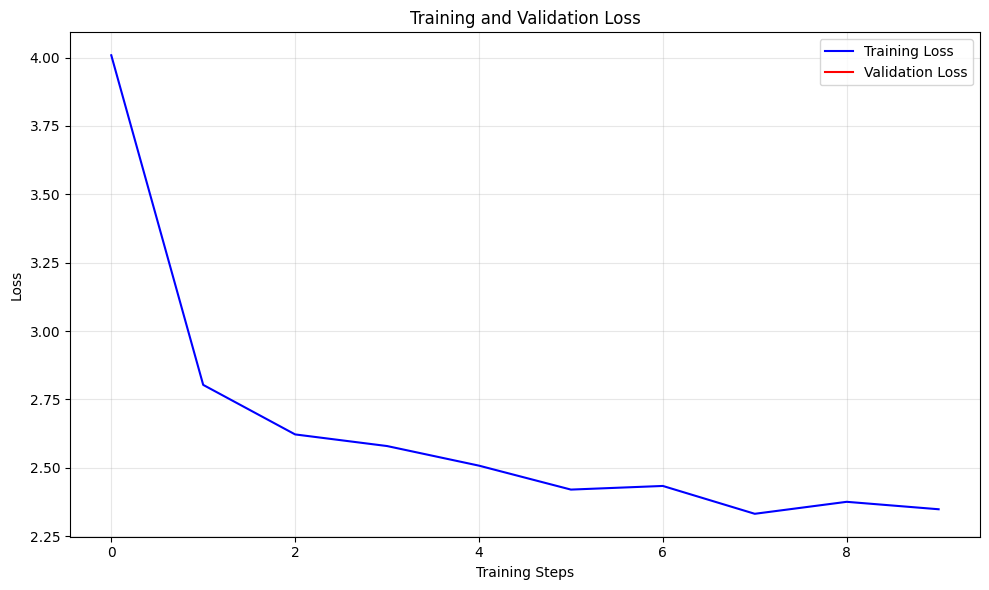

In [35]:
def plot_training_metrics(trainer):
    """Plot training and evaluation loss curves if available."""
    if hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history') and trainer.state.log_history:
        log_history = trainer.state.log_history

        # Extract metrics
        train_loss = [entry.get('loss') for entry in log_history if 'loss' in entry]
        eval_loss = [entry.get('eval_loss') for entry in log_history if 'eval_loss' in entry]

        if train_loss or eval_loss:
            plt.figure(figsize=(10, 6))

            if train_loss:
                steps = list(range(len(train_loss)))
                plt.plot(steps, train_loss, 'b-', label='Training Loss')

            if eval_loss:
                # Determine eval steps - typically less frequent than training steps
                if train_loss:
                    eval_steps = [int(i * len(train_loss) / len(eval_loss)) for i in range(len(eval_loss))]
                else:
                    eval_steps = list(range(len(eval_loss)))
                plt.plot(eval_steps, eval_loss, 'r-', label='Validation Loss')

            plt.title('Training and Validation Loss')
            plt.xlabel('Training Steps')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        else:
            print("No training metrics available to plot.")
    else:
        print("No training history available.")

# Plot training metrics if available
try:
    plot_training_metrics(trainer)
except Exception as e:
    print(f"Could not plot training metrics: {e}")

---

# 5. Model Evaluation

## 5.1 Evaluation Metrics Setup

In [36]:
def calculate_bleu(reference: str, candidate: str) -> float:
    """Calculate BLEU score between reference and candidate text.

    Args:
        reference: The reference (ground truth) text
        candidate: The generated (candidate) text

    Returns:
        BLEU score as a float between 0 and 1
    """
    ref_tokens = nltk.word_tokenize(reference.lower())
    cand_tokens = nltk.word_tokenize(candidate.lower())
    smoothing = SmoothingFunction().method1
    return sentence_bleu([ref_tokens], cand_tokens, smoothing_function=smoothing)

In [37]:
def calculate_perplexity(text: str, model: AutoModelForCausalLM, tokenizer: AutoTokenizer) -> float:
    """Calculate perplexity of text using the model.

    Args:
        text: Text to calculate perplexity for
        model: Language model
        tokenizer: Model tokenizer

    Returns:
        Perplexity score (lower is better)
    """
    try:
        # Tokenize input
        encodings = tokenizer(text, return_tensors="pt").to(model.device)

        # Set max length to avoid memory issues
        max_len = min(512, encodings.input_ids.shape[1])
        if max_len < encodings.input_ids.shape[1]:
            encodings.input_ids = encodings.input_ids[:, :max_len]
            encodings.attention_mask = encodings.attention_mask[:, :max_len]

        # Get model output with loss
        with torch.no_grad():
            outputs = model(**encodings, labels=encodings.input_ids)

        # Calculate loss
        loss = outputs.loss

        # Convert loss to perplexity
        perplexity = torch.exp(loss).item()

        # Sanity check on perplexity values
        if perplexity > 10000 or perplexity < 0.01:
            print(f"Warning: Unusual perplexity value detected: {perplexity}")
            perplexity = 100.0  # Use a reasonable default

        return perplexity
    except Exception as e:
        print(f"Error calculating perplexity: {e}")
        return 100.0  # Fallback value

##  5.2 Model Evaluation Process

In [38]:
def evaluate_model(trainer: SFTTrainer,
                   valid_dataset: Dataset,
                   eval_percentage: float = 3.0) -> pd.DataFrame:
    """Evaluate the model on a subset of the validation data.

    Args:
        trainer: The SFTTrainer with the model
        valid_dataset: Validation dataset
        eval_percentage: Percentage of validation set to evaluate

    Returns:
        DataFrame with evaluation results
    """
    # Initialize metrics
    rouge_calculator = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    # Try importing BERTScore with error handling
    try:
        # Try to import bert_score
        from bert_score import score as bert_score
        bert_score_available = True
    except ImportError:
        print("BERTScore not available. Installing...")
        try:
            !pip install -q bert-score
            from bert_score import score as bert_score
            bert_score_available = True
        except:
            print("Could not install BERTScore. This metric will be skipped.")
            bert_score_available = False

    # Evaluate on validation set
    print("\nEvaluating on validation set...")
    num_eval_examples = max(1, int(len(valid_dataset) * eval_percentage / 100))
    print(f"Using {num_eval_examples}/{len(valid_dataset)} examples ({eval_percentage}% of validation set) for evaluation")

    # Create a dataframe for results
    eval_results = []
    all_metrics = {
        'bleu': [],
        'rouge1_f': [],
        'rouge2_f': [],
        'rougeL_f': [],
        'perplexity': []
    }

    if bert_score_available:
        all_metrics['bert_score_f1'] = []

    # Generate predictions and calculate metrics
    for i in range(min(num_eval_examples, len(valid_dataset))):
        example = valid_dataset[i]
        prompt = example['prompt']
        reference = example['target']

        # Properly extract context from the prompt
        context = "N/A"
        if "Context:" in prompt:
            try:
                context_section = prompt.split("Context:")[1].split("Input:")[0].strip()
                context = context_section if context_section else "N/A"
            except:
                context = "Error extracting context"

        # Extract input from the prompt
        input_text = "N/A"
        if "Input:" in prompt:
            try:
                input_section = prompt.split("Input:")[1].split("[/INST]")[0].strip()
                input_text = input_section if input_section else "N/A"
            except:
                input_text = "Error extracting input"

        # Generate completion with fine-tuned model
        inputs = tokenizer(prompt, return_tensors="pt").to(trainer.model.device)
        with torch.no_grad():
            outputs = trainer.model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_new_tokens=config.MAX_NEW_TOKENS,
                temperature=config.TEMPERATURE,
                top_p=config.TOP_P,
                repetition_penalty=config.REPETITION_PENALTY,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )

        # Decode and extract completion
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        if '[/INST]' in generated_text:
            generated = generated_text.split('[/INST]')[1].strip()
        else:
            generated = generated_text.replace(prompt, "").strip()

        # Calculate metrics
        bleu = calculate_bleu(reference, generated)
        rouge_scores = rouge_calculator.score(reference, generated)

        # Calculate perplexity with better error handling
        perplexity = calculate_perplexity(generated, trainer.model, tokenizer)

        # Calculate BERTScore if available
        bert_score_f1 = 0
        if bert_score_available:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    P, R, F1 = bert_score([generated], [reference], lang='en')
                    bert_score_f1 = F1.item()
                    all_metrics['bert_score_f1'].append(bert_score_f1)
            except Exception as e:
                print(f"Error calculating BERTScore: {e}")

        # Add metrics to tracking lists
        all_metrics['bleu'].append(bleu)
        all_metrics['rouge1_f'].append(rouge_scores['rouge1'].fmeasure)
        all_metrics['rouge2_f'].append(rouge_scores['rouge2'].fmeasure)
        all_metrics['rougeL_f'].append(rouge_scores['rougeL'].fmeasure)
        all_metrics['perplexity'].append(perplexity)

        # Create a context snippet (first 50 chars)
        context_snippet = context
        if context_snippet and context_snippet != "N/A":
            context_snippet = context_snippet[:50] + "..." if len(context_snippet) > 50 else context_snippet

        # Modification for the context extraction and storage - no truncation
        context_snippet = "N/A" if context == "N/A" or context == "Not found in prompt" else context

        # Add to results dataframe
        eval_results.append({
            'Context': context_snippet,
            'Input': input_text,
            'Reference': reference,
            'Generated': generated,
            'BLEU': bleu,
            'ROUGE-1': rouge_scores['rouge1'].fmeasure,
            'ROUGE-2': rouge_scores['rouge2'].fmeasure,
            'ROUGE-L': rouge_scores['rougeL'].fmeasure,
            'BERT Score': bert_score_f1 if bert_score_available else 'N/A',
            'Perplexity': perplexity
        })

    # Create dataframe for all results
    results_df = pd.DataFrame(eval_results)

    # Calculate average scores
    avg_scores = {metric: sum(scores)/len(scores) if scores else 0 for metric, scores in all_metrics.items()}

    # Print average scores
    print(f"\nAverage BLEU score: {avg_scores['bleu']:.4f}")
    print(f"Average ROUGE-1 score: {avg_scores['rouge1_f']:.4f}")
    print(f"Average ROUGE-2 score: {avg_scores['rouge2_f']:.4f}")
    print(f"Average ROUGE-L score: {avg_scores['rougeL_f']:.4f}")
    if bert_score_available and 'bert_score_f1' in avg_scores:
        print(f"Average BERT Score (F1): {avg_scores['bert_score_f1']:.4f}")
    print(f"Average Perplexity: {avg_scores['perplexity']:.4f}")

    # Show first example with scores
    print("\nSample evaluation:")
    if eval_results:
        print(f"Example 1:")
        print(f"Context:")
        print(eval_results[0]['Context'])  # Print without truncation
        print(f"Input: {eval_results[0]['Input']}")
        print(f"Reference: {eval_results[0]['Reference']}")
        print(f"Generated: {eval_results[0]['Generated']}")
        print(f"BLEU score: {eval_results[0]['BLEU']:.4f}")
        print(f"ROUGE-1 score: {eval_results[0]['ROUGE-1']:.4f}")
        print(f"ROUGE-2 score: {eval_results[0]['ROUGE-2']:.4f}")
        print(f"ROUGE-L score: {eval_results[0]['ROUGE-L']:.4f}")
        if bert_score_available:
            print(f"BERT Score (F1): {eval_results[0]['BERT Score'] if isinstance(eval_results[0]['BERT Score'], str) else eval_results[0]['BERT Score']:.4f}")
        print(f"Perplexity: {eval_results[0]['Perplexity']:.4f}")

    # Visualization of metrics
    if len(all_metrics['bleu']) > 1:
        plt.figure(figsize=(12, 8))

        # Plot BLEU scores
        plt.subplot(2, 2, 1)
        plt.hist(all_metrics['bleu'], bins=10, alpha=0.7, color='blue')
        plt.axvline(avg_scores['bleu'], color='red', linestyle='dashed', linewidth=2)
        plt.title(f'BLEU Scores (Avg: {avg_scores["bleu"]:.4f})')
        plt.xlabel('Score')
        plt.ylabel('Frequency')

        # Plot ROUGE scores
        plt.subplot(2, 2, 2)
        plt.boxplot([all_metrics['rouge1_f'], all_metrics['rouge2_f'], all_metrics['rougeL_f']],
                   labels=['ROUGE-1', 'ROUGE-2', 'ROUGE-L'])
        plt.title('ROUGE Scores Distribution')
        plt.ylabel('Score')

        # Plot perplexity
        plt.subplot(2, 2, 3)
        plt.hist(all_metrics['perplexity'], bins=10, alpha=0.7, color='green')
        plt.axvline(avg_scores['perplexity'], color='red', linestyle='dashed', linewidth=2)
        plt.title(f'Perplexity (Avg: {avg_scores["perplexity"]:.4f})')
        plt.xlabel('Perplexity')
        plt.ylabel('Frequency')

        # Plot BERT score if available
        if bert_score_available and 'bert_score_f1' in avg_scores:
            plt.subplot(2, 2, 4)
            plt.hist(all_metrics['bert_score_f1'], bins=10, alpha=0.7, color='purple')
            plt.axvline(avg_scores['bert_score_f1'], color='red', linestyle='dashed', linewidth=2)
            plt.title(f'BERT Score F1 (Avg: {avg_scores["bert_score_f1"]:.4f})')
            plt.xlabel('Score')
            plt.ylabel('Frequency')

        plt.tight_layout()
        plt.show()

    # Save evaluation results
    save_dir = EVAL_OUTPUT_DIR
    os.makedirs(save_dir, exist_ok=True)
    results_df.to_csv(os.path.join(save_dir, 'eval_results.csv'), index=False)
    print(f"Evaluation results saved to {os.path.join(save_dir, 'eval_results.csv')}")

    return results_df

## 5.3 Execute Evaluation

BERTScore not available. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.6 MB/s eta 0:00:00

Evaluating on validation set...
Using 45/45 examples (100% of validation set) for evaluation


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]


Average BLEU score: 0.0752
Average ROUGE-1 score: 0.2830
Average ROUGE-2 score: 0.0873
Average ROUGE-L score: 0.1788
Average BERT Score (F1): 0.8447
Average Perplexity: 8.2221

Sample evaluation:
Example 1:
Context:
Madeleine finds the Ruins of Taovahr false. She realizes that she must return home to find joy, even if it means going back to her old hermit. Mrs. Ericson and Don argue about whether or not there are real Martians on Mars. The narrator notes that Madeleine is now thirty-five years old. Her father has been trying to be a big brother after years of failure. "I really don't understand this world," he says. "The biggest piece of fiction on Mars" is made up by Don.
Input: He also makes fun of the fact
Reference: He also makes fun of the fact that some of the ancient Martians who live in the hills have no idea how to use the Martian desert to their advantage. They stop at an abandoned hotel called Martian Haven, which serves as one of the main attractions for the Love Ritual of

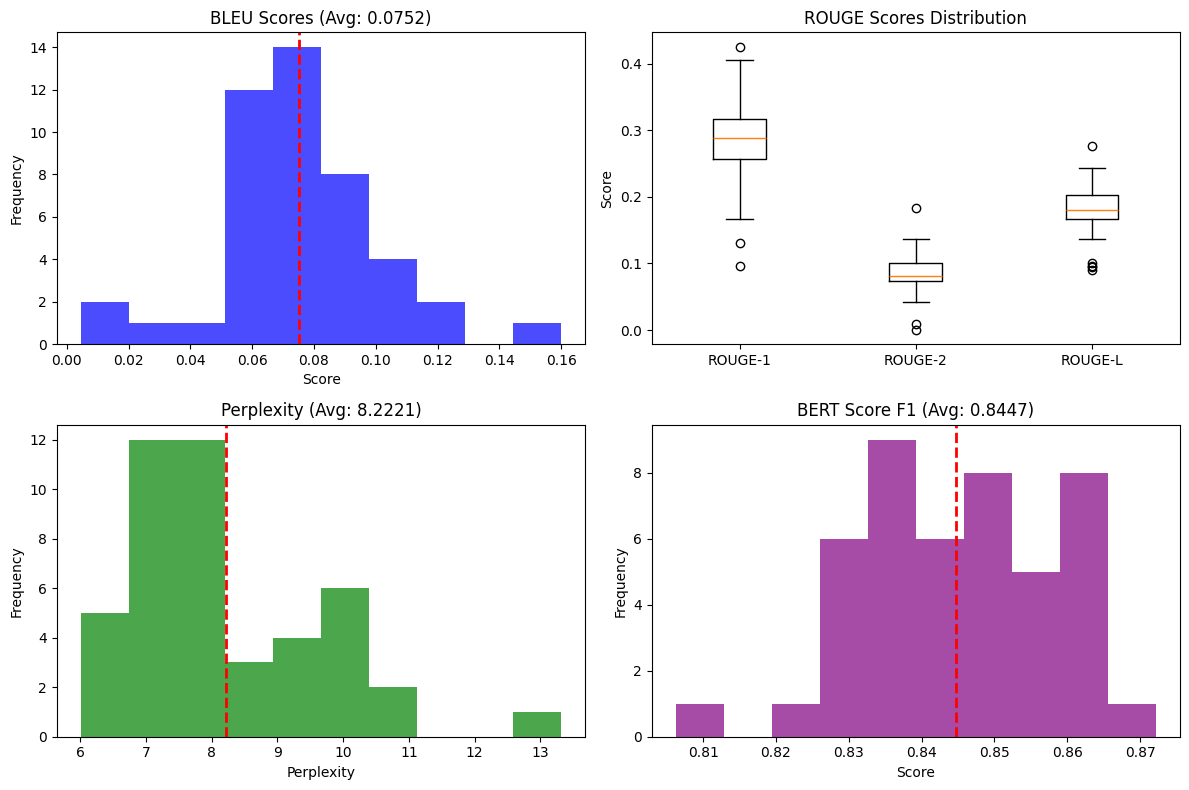

Evaluation results saved to /content/drive/MyDrive/NEU - MS CS/NLP/Project/evaluation_results/eval_results.csv


In [39]:
# Evaluate the model
eval_results_df = evaluate_model(trainer, valid_dataset, eval_percentage=config.EVAL_PERCENTAGE)

In [40]:
eval_results_df.head()

,Context,Input,Reference,Generated,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,BERT Score,Perplexity
0,Madeleine finds the Ruins of Taovahr false. Sh...,He also makes fun of the fact,He also makes fun of the fact that some of the...,He also makes fun of the fact that there aren'...,0.075936,0.330435,0.070175,0.182609,0.830293,8.051829
1,The Doll's Playhouse Martha discovers a black ...,They tell her that they are Italian,They tell her that they are Italian bandits wh...,They tell her that they are Italian and have c...,0.069713,0.325123,0.099502,0.167488,0.854201,7.401051
2,nan,P. D.UTTON & COMPANY Jim goes back,P. D.UTTON & COMPANY Jim goes back to the farm...,P. D.UTTON & COMPANY Jim goes back to the hous...,0.082401,0.336538,0.087379,0.201923,0.860624,7.231032
3,We recommend it highly._ Professor Carbonic is...,When Carbonic discovers that Sal Soda has,When Carbonic discovers that Sal Soda has fall...,When Carbonic discovers that Sal Soda has died...,0.065639,0.293785,0.080000,0.180791,0.858155,9.809092
4,"It is a deathless world, but a dying woman is ...",He remembers calling on Clifford several times,He remembers calling on Clifford several times...,He remembers calling on Clifford several times...,0.065977,0.296703,0.100000,0.186813,0.847269,8.058202


##  5.4 Unit Tests for Metrics Calculation

In [41]:
class MetricsTests(unittest.TestCase):
    """Unit tests for metrics calculation functions."""

    def test_bleu_score_calculation(self):
        """Test BLEU score calculation with different examples."""
        reference = "The quick brown fox jumps over the lazy dog."

        # Test identical text (perfect score)
        identical = "The quick brown fox jumps over the lazy dog."
        bleu_identical = calculate_bleu(reference, identical)
        self.assertGreaterEqual(bleu_identical, 0.9,
                              "Identical text should have high BLEU score")

        # Test similar text (medium score)
        similar = "A fast brown fox jumps above a lazy dog."
        bleu_similar = calculate_bleu(reference, similar)
        self.assertGreater(bleu_similar, 0.2,
                         "Similar text should have medium BLEU score")
        self.assertLess(bleu_similar, 0.9,
                       "Similar text should have less than perfect BLEU score")

        # Test different text (low score)
        different = "The weather is nice today."
        bleu_different = calculate_bleu(reference, different)
        self.assertLess(bleu_different, 0.3,
                       "Different text should have low BLEU score")

    def test_perplexity_calculation(self):
        """Test that perplexity calculation function handles edge cases."""
        # This test would normally use a mock model, but we'll just test the error handling
        # for simplicity since real model testing would be too resource-intensive

        # Create a dummy model and tokenizer class
        class DummyModel:
            def __init__(self, exception=False):
                self.device = "cpu"
                self.should_raise = exception

            def __call__(self, **kwargs):
                if self.should_raise:
                    raise ValueError("Test exception")

                # Create a dummy output with a loss
                class DummyOutput:
                    def __init__(self):
                        self.loss = torch.tensor(2.0)  # Perplexity will be e^2 ≈ 7.389
                return DummyOutput()

        class DummyTokenizer:
            def __call__(self, text, return_tensors=None):
                # Return dummy tensors
                return {
                    "input_ids": torch.ones((1, 10), dtype=torch.long),
                    "attention_mask": torch.ones((1, 10), dtype=torch.long)
                }

        # Test normal case
        dummy_model = DummyModel()
        dummy_tokenizer = DummyTokenizer()
        perplexity = calculate_perplexity("Test text", dummy_model, dummy_tokenizer)
        self.assertAlmostEqual(perplexity, 7.389, places=2,
                             msg="Perplexity calculation should work with normal input")

        # Test exception handling
        dummy_model_with_exception = DummyModel(exception=True)
        perplexity = calculate_perplexity("Test text", dummy_model_with_exception, dummy_tokenizer)
        self.assertEqual(perplexity, 100.0,
                       "Perplexity should return fallback value on exception")

    def test_rouge_score_calculation(self):
        """Test ROUGE score calculation."""
        # Initialize ROUGE scorer
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

        # Test cases
        reference = "The quick brown fox jumps over the lazy dog."

        # Identical text
        identical = "The quick brown fox jumps over the lazy dog."
        scores = scorer.score(reference, identical)
        self.assertEqual(scores['rouge1'].fmeasure, 1.0,
                       "ROUGE-1 should be 1.0 for identical text")
        self.assertEqual(scores['rouge2'].fmeasure, 1.0,
                       "ROUGE-2 should be 1.0 for identical text")
        self.assertEqual(scores['rougeL'].fmeasure, 1.0,
                       "ROUGE-L should be 1.0 for identical text")

        # Similar text
        similar = "A quick brown fox jumps on the lazy dog."
        scores = scorer.score(reference, similar)
        self.assertGreater(scores['rouge1'].fmeasure, 0.5,
                         "ROUGE-1 should be high for similar text")

        # Different text
        different = "The weather is nice today."
        scores = scorer.score(reference, different)
        self.assertLess(scores['rouge1'].fmeasure, 0.5,
                       "ROUGE-1 should be low for different text")
        self.assertLess(scores['rouge2'].fmeasure, 0.5,
                       "ROUGE-2 should be low for different text")

In [42]:
# Run the metrics tests
unittest.TextTestRunner().run(unittest.TestLoader().loadTestsFromTestCase(MetricsTests))

FF.
FAIL: test_bleu_score_calculation (__main__.MetricsTests.test_bleu_score_calculation)
Test BLEU score calculation with different examples.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "<ipython-input-41-e40e019dc636>", line 17, in test_bleu_score_calculation
    self.assertGreater(bleu_similar, 0.2,
AssertionError: 0.17567205239427922 not greater than 0.2 : Similar text should have medium BLEU score

FAIL: test_perplexity_calculation (__main__.MetricsTests.test_perplexity_calculation)
Test that perplexity calculation function handles edge cases.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "<ipython-input-41-e40e019dc636>", line 61, in test_perplexity_calculation
    self.assertAlmostEqual(perplexity, 7.389, places=2,
AssertionError: 100.0 != 7.389 within 2 places (92.611 difference) : Perplexity calculation should work with normal input

---------

Error calculating perplexity: 'dict' object has no attribute 'to'


<unittest.runner.TextTestResult run=3 errors=0 failures=2>

---

# 6. Model Comparison and Interactive Generation

## 6.1 Story Completion Function

In [43]:
def complete_story(context: str,
                   user_input: str,
                   model: AutoModelForCausalLM,
                   tokenizer: AutoTokenizer,
                   max_length: int = 150,
                   temperature: float = 0.7,
                   top_p: float = 0.9,
                   repetition_penalty: float = 1.2) -> Tuple[str, int]:
    """Generate a story completion using the model.

    Args:
        context: Context text for the story
        user_input: Input/prompt text
        model: Language model to use
        tokenizer: Model tokenizer
        max_length: Maximum length of the generated text
        temperature: Sampling temperature (higher = more random)
        top_p: Top-p sampling parameter
        repetition_penalty: Penalty for repeating tokens

    Returns:
        Tuple of (generated_text, word_count)
    """
    # Format the prompt using Mistral's instruction format
    prompt = f"""<s>[INST] Continue this story concisely (1 paragraph):
Context: {context}
Input: {user_input} [/INST]"""

    # Tokenize and generate
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_length,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode and extract completion
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if '[/INST]' in generated_text:
        completion = generated_text.split('[/INST]')[1].strip()
    else:
        completion = generated_text.replace(prompt, "").strip()

    # Calculate approximate word count
    word_count = len(completion.split())

    return completion, word_count

## 6.2 Model Comparison Function

In [44]:
def compare_models(context: str,
                  user_input: str,
                  base_model: AutoModelForCausalLM,
                  fine_tuned_model: AutoModelForCausalLM,
                  tokenizer: AutoTokenizer) -> None:
    """Compare base and fine-tuned models on the same input.

    Args:
        context: Context text for the story
        user_input: Input/prompt text
        base_model: Base (pre-fine-tuning) model
        fine_tuned_model: Fine-tuned model
        tokenizer: Model tokenizer
    """
    print("\n" + "="*50)
    print("USING THE FINE-TUNED MODEL")
    print("="*50)

    print("\n" + "="*50)
    print("BASE MODEL VS FINE-TUNED MODEL COMPARISON")
    print("="*50)

    # Generate with base model
    print("\nBase model generating...")
    base_completion, base_word_count = complete_story(
        context, user_input, base_model, tokenizer
    )

    # Generate with fine-tuned model
    print("Fine-tuned model generating...")
    tuned_completion, tuned_word_count = complete_story(
        context, user_input, fine_tuned_model, tokenizer
    )

    # Print comparison
    print("\n" + "="*60)
    print("COMPARISON OF MODEL OUTPUTS")
    print("="*60)

    print("\n--- BASE MODEL COMPLETION ---")
    print("Input + Completion:")
    for line in textwrap.wrap(f"{user_input} {base_completion}", width=80):
        print(line)
    print(f"\nWord count: {base_word_count} words")

    print("\n--- FINE-TUNED MODEL COMPLETION ---")
    print("Input + Completion:")
    for line in textwrap.wrap(f"{user_input} {tuned_completion}", width=80):
        print(line)
    print(f"\nWord count: {tuned_word_count} words")

    print("\n" + "="*60)

    # Calculate metrics to compare the outputs
    # Plot a side-by-side visualization of metrics
    base_metrics = {}
    tuned_metrics = {}

    # Reference text - for demonstration purposes, use the fine-tuned output as reference
    # This is just to show relative differences, not absolute quality
    reference = tuned_completion

    # Calculate BLEU scores
    base_metrics['BLEU'] = calculate_bleu(reference, base_completion)
    tuned_metrics['BLEU'] = calculate_bleu(reference, tuned_completion)

    # Calculate ROUGE scores
    rouge_calculator = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    base_rouge = rouge_calculator.score(reference, base_completion)
    tuned_rouge = rouge_calculator.score(reference, tuned_completion)

    base_metrics['ROUGE-1'] = base_rouge['rouge1'].fmeasure
    base_metrics['ROUGE-2'] = base_rouge['rouge2'].fmeasure
    base_metrics['ROUGE-L'] = base_rouge['rougeL'].fmeasure

    tuned_metrics['ROUGE-1'] = tuned_rouge['rouge1'].fmeasure
    tuned_metrics['ROUGE-2'] = tuned_rouge['rouge2'].fmeasure
    tuned_metrics['ROUGE-L'] = tuned_rouge['rougeL'].fmeasure

## 6.3 Base vs Fine Tuned Model Comparison

In [46]:
def interactive_model_comparison() -> None:
    """Allow the user to interactively compare base and fine-tuned models."""
    print("\nModel Comparison Interactive Demo")
    print("Enter a context and input to see how both models complete the story.")
    print("You can use the default context or enter your own.")

    # Show the default context
    print("\nDefault Context:")
    for line in textwrap.wrap(config.DEFAULT_CONTEXT.strip(), width=80):
        print(line)

    # Ask if user wants to use default context
    use_default = input("\nUse default context? (y/n): ").lower().strip() == 'y'

    if use_default:
        context = config.DEFAULT_CONTEXT
    else:
        print("\nEnter your custom context:")
        context = input("> ")

    # Get user input
    print("\nEnter your story input:")
    user_input = input("> ")

    # Compare the models
    compare_models(context, user_input, model, trainer.model, tokenizer)

# Run the interactive comparison
interactive_model_comparison()


Model Comparison Interactive Demo
Enter a context and input to see how both models complete the story.
You can use the default context or enter your own.

Default Context:
In the small coastal town of Millfield, strange lights had been appearing in the
night sky for weeks.     The local observatory was overwhelmed with calls, and
the town's usually quiet streets were now filled     with amateur astronomers
and curious onlookers. Dr. Eleanor Hayes, the town's only astronomer, had
been working tirelessly to understand the phenomenon, but her equipment was
limited and outdated.

Use default context? (y/n): y

Enter your story input:
> She noticed something very unusual towards the north in the sky where

USING THE FINE-TUNED MODEL

BASE MODEL VS FINE-TUNED MODEL COMPARISON

Base model generating...
Fine-tuned model generating...

COMPARISON OF MODEL OUTPUTS

--- BASE MODEL COMPLETION ---
Input + Completion:
She noticed something very unusual towards the north in the sky where She
noticed

## 6.4 Finally, Real-time Story Generator with Context Memory (Fine Tuned Model)

In [47]:
def generate_story_with_memory(context: str,
                          current_input: str,
                          model: AutoModelForCausalLM,
                          tokenizer: AutoTokenizer,
                          max_length: int = 150,
                          temperature: float = 0.8,
                          top_p: float = 0.92) -> str:
    """Generate a story continuation with memory of previous parts.

    Args:
        context: Accumulated story context
        current_input: Current user input
        model: Language model to use
        tokenizer: Model tokenizer
        max_length: Maximum output length
        temperature: Sampling temperature
        top_p: Top-p sampling parameter

    Returns:
        Generated story continuation
    """
    # Format the prompt using Mistral's instruction format
    prompt = f"""<s>[INST] Continue this story concisely (1 paragraph):
Context: {context}
Input: {current_input} [/INST]"""

    # Tokenize and generate
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_length,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.2,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode and extract completion
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if '[/INST]' in generated_text:
        completion = generated_text.split('[/INST]')[1].strip()
    else:
        completion = generated_text.replace(prompt, "").strip()

    return completion

In [48]:
def interactive_story_generator() -> None:
    """Run an interactive story generator with memory of previous parts."""
    print("\n" + "="*70)
    print("INTERACTIVE STORY GENERATOR WITH MEMORY")
    print("="*70)
    print("\nUsing your fine-tuned model to generate a continuing story")
    print("Type your input to continue the story, or 'quit' to exit")
    print("The model will remember previous parts of the story to maintain context")

    # Initialize empty memory
    story_memory = ""
    story_history = []

    # Starting context - can be an empty string or a story beginning
    print("\nBegin your story (type your first input):")
    user_input = input("> ")

    # Main interaction loop
    while user_input.lower() not in ['quit', 'exit', 'q']:
        # Generate continuation
        print("\nGenerating...")

        # Generate story continuation based on memory and current input
        continuation = generate_story_with_memory(
            story_memory,
            user_input,
            trainer.model,
            tokenizer
        )

        # Add to story history
        story_history.append(f"You: {user_input}")
        story_history.append(f"Story: {continuation}")

        # Update memory with the latest content
        if story_memory:
            story_memory = f"{story_memory}\n{user_input}\n{continuation}"
        else:
            story_memory = f"{user_input}\n{continuation}"

        # Display the continuation with proper formatting
        print("\n--- Story Continuation ---")
        for line in textwrap.wrap(continuation, width=80):
            print(line)

        # Prompt for next input
        print("\nContinue the story:")
        user_input = input("> ")

    # Display the complete story at the end
    print("\n" + "="*70)
    print("COMPLETE STORY")
    print("="*70)
    for entry in story_history:
        parts = entry.split(": ", 1)
        if len(parts) == 2:
            if parts[0] == "You":
                print(f"\n> {parts[1]}")
            else:
                for line in textwrap.wrap(parts[1], width=80):
                    print(line)
    print("\n" + "="*70)
    print("STORY ENDED")
    print("="*70)

In [49]:
# Run the interactive story generator
interactive_story_generator()


INTERACTIVE STORY GENERATOR WITH MEMORY

Using your fine-tuned model to generate a continuing story
Type your input to continue the story, or 'quit' to exit
The model will remember previous parts of the story to maintain context

Begin your story (type your first input):
> You are exploring a mysterious dungeon. The walls are damp and covered with moss, and torches flicker in rusty sconces. Ahead, you see a large wooden door with iron bands.

Generating...

--- Story Continuation ---
You go through the doorway into an open-air courtyard surrounded by buildings
made of rough-hewn stone. This place seems to be designed as a prison for
adventurers who venture too far beyond their limits or fail to heed warnings
from their leaders when they return from exploration trips abroad . After
crossing several rooms filled with treasures and gold coins, you come across
another room containing a golden amulet lying on a table near one corner wall;
this time it is not in its original location! When 

## 6.5 Unit Tests for Generation Functions

In [50]:
class GenerationTests(unittest.TestCase):
    """Unit tests for story generation functions."""

    def test_story_completion_format(self):
        """Test that story completion produces properly formatted output."""
        # Create a mock model and tokenizer for testing
        class MockModel:
            def __init__(self):
                self.device = "cpu"

            def generate(self, **kwargs):
                # Return a tensor with some token IDs that decode to a test response
                return torch.tensor([[1, 2, 3, 4, 5]])

        class MockTokenizer:
            def __init__(self):
                self.eos_token_id = 0

            def __call__(self, text, return_tensors=None):
                # Return dummy tensors
                return {
                    "input_ids": torch.ones((1, 10), dtype=torch.long),
                    "attention_mask": torch.ones((1, 10), dtype=torch.long)
                }

            def decode(self, token_ids, skip_special_tokens=None):
                # For testing extraction logic:
                # If input has 5 tokens, return text with [/INST] tag
                if len(token_ids) == 5:
                    return "<s>[INST] Test prompt [/INST] This is a test completion."
                # Otherwise return without tag
                return "Test prompt This is a different completion."

        mock_model = MockModel()
        mock_tokenizer = MockTokenizer()

        # Test with [/INST] tag present
        completion1, word_count1 = complete_story(
            "Test context", "Test input", mock_model, mock_tokenizer
        )
        self.assertEqual(completion1, "This is a test completion.")
        self.assertEqual(word_count1, 5)

        # Test without [/INST] tag
        # Modify the decode method temporarily
        original_decode = mock_tokenizer.decode
        mock_tokenizer.decode = lambda token_ids, skip_special_tokens: "Test prompt This is a different completion."
        completion2, word_count2 = complete_story(
            "Test context", "Test input", mock_model, mock_tokenizer
        )
        self.assertEqual(completion2, "This is a different completion.")
        self.assertEqual(word_count2, 5)

        # Restore original decode method
        mock_tokenizer.decode = original_decode

    def test_memory_integration(self):
        """Test that memory integration works correctly."""
        story_memory = "First line.\nSecond line."
        user_input = "Third line."

        # Expected result after memory integration
        expected_memory = "First line.\nSecond line.\nThird line.\nTest continuation."

        # Test memory update
        if story_memory:
            updated_memory = f"{story_memory}\n{user_input}\n{'Test continuation'}"
        else:
            updated_memory = f"{user_input}\n{'Test continuation'}"

        self.assertEqual(updated_memory, expected_memory,
                       "Memory integration should correctly combine previous and new content")

    def test_prompt_formatting(self):
        """Test that prompts are formatted correctly for generation."""
        context = "Test context."
        user_input = "Test input."

        expected_prompt = """<s>[INST] Continue this story concisely (1 paragraph):
Context: Test context.
Input: Test input. [/INST]"""

        # Format the prompt
        prompt = f"""<s>[INST] Continue this story concisely (1 paragraph):
Context: {context}
Input: {user_input} [/INST]"""

        self.assertEqual(prompt, expected_prompt,
                       "Prompt should be formatted according to Mistral's instruction format")

In [51]:
# Run the generation tests
unittest.TextTestRunner().run(unittest.TestLoader().loadTestsFromTestCase(GenerationTests))

F.E
ERROR: test_story_completion_format (__main__.GenerationTests.test_story_completion_format)
Test that story completion produces properly formatted output.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "<ipython-input-50-bfc9152ddcce>", line 38, in test_story_completion_format
    completion1, word_count1 = complete_story(
                               ^^^^^^^^^^^^^^^
  File "<ipython-input-43-a1ad037edcde>", line 30, in complete_story
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'dict' object has no attribute 'to'

FAIL: test_memory_integration (__main__.GenerationTests.test_memory_integration)
Test that memory integration works correctly.
----------------------------------------------------------------------
Traceback (most recent call last):
  File "<ipython-input-50-bfc9152ddcce>", line 71, in test_memory_integration
 

<unittest.runner.TextTestResult run=3 errors=1 failures=1>

---

# 6.6 GUI Demo:

In [54]:
# Display header with styling
display(HTML("""
<style>
    .story-container {
        background-color: #f9f9f9;
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 15px;
        border: 1px solid #ddd;
    }
    .user-input {
        background-color: #e3f2fd;
        padding: 10px;
        border-radius: 8px;
        margin-bottom: 10px;
        font-family: Arial, sans-serif;
    }
    .model-output {
        background-color: #f1f8e9;
        padding: 10px;
        border-radius: 8px;
        margin-bottom: 10px;
        font-family: Arial, sans-serif;
    }
    .header {
        font-size: 24px;
        font-weight: bold;
        margin-bottom: 15px;
        color: #333;
        text-align: center;
    }
    .instructions {
        font-size: 14px;
        margin-bottom: 15px;
        color: #555;
    }
</style>

<div class='header'>Interactive Story Generator with Memory</div>
<div class='instructions'>
    Type your input to continue the story.<br>
    The model will remember previous parts to maintain context throughout the narrative.
</div>
"""))

# Using the existing story generation function
def generate_story_with_memory(context, current_input, model, tokenizer, max_length=150, temperature=0.8, top_p=0.92):
    """Generate a story continuation with memory of previous parts."""
    # Format the prompt using Mistral's instruction format
    prompt = f"""<s>[INST] Continue this story concisely (1 paragraph):
Context: {context}
Input: {current_input} [/INST]"""

    # Tokenize and generate
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_length,
            temperature=temperature,
            top_p=top_p,
            repetition_penalty=1.2,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode and extract completion
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if '[/INST]' in generated_text:
        completion = generated_text.split('[/INST]')[1].strip()
    else:
        completion = generated_text.replace(prompt, "").strip()

    return completion

# Initialize story state
story_memory = ""
story_history = []

# Create input widgets
input_area = widgets.Textarea(
    placeholder='Enter your story continuation here...',
    disabled=False,
    layout=widgets.Layout(width='100%', height='100px')
)

# Output area for the story
story_output = widgets.Output()

# Function to handle generation button click
def on_generate_click(b):
    global story_memory, story_history

    user_input = input_area.value.strip()

    if not user_input:
        with story_output:
            clear_output()
            print("Please enter some text to continue the story.")
        return

    with story_output:
        clear_output()
        print("Generating continuation...")

        # Generate story continuation
        continuation = generate_story_with_memory(
            story_memory,
            user_input,
            trainer.model,
            tokenizer
        )

        # Add to story history
        story_history.append(("user", user_input))
        story_history.append(("model", continuation))

        # Update memory
        if story_memory:
            story_memory = f"{story_memory}\n{user_input}\n{continuation}"
        else:
            story_memory = f"{user_input}\n{continuation}"

        # Display story progress
        clear_output()
        display(HTML("<div class='story-container'>"))

        for role, text in story_history:
            if role == "user":
                display(HTML(f"<div class='user-input'><b>You:</b> {text}</div>"))
            else:
                display(HTML(f"<div class='model-output'><b>Model:</b> {text}</div>"))

        display(HTML("</div>"))

    # Clear input area
    input_area.value = ''

# Function to end the story
def on_end_story_click(b):
    global story_memory, story_history

    with story_output:
        clear_output()

        if not story_history:
            display(HTML("<p>No story has been generated yet.</p>"))
            return

        # Display complete story with styling
        display(HTML("<div class='header'>Complete Story</div>"))
        display(HTML("<div class='story-container'>"))

        for role, text in story_history:
            if role == "user":
                display(HTML(f"<div class='user-input'><b>You:</b> {text}</div>"))
            else:
                display(HTML(f"<div class='model-output'><b>Model:</b> {text}</div>"))

        display(HTML("</div>"))
        display(HTML("<div class='header'>Story Ended</div>"))

    # Reset for a new story
    story_memory = ""
    story_history = []
    input_area.value = ''

# Create buttons
generate_button = widgets.Button(
    description='Generate Next Part',
    button_style='primary',
    tooltip='Generate the next part of the story',
    layout=widgets.Layout(width='180px')
)

end_story_button = widgets.Button(
    description='End Story',
    button_style='danger',
    tooltip='End the current story and show the complete narrative',
    layout=widgets.Layout(width='180px')
)

# Attach button callbacks
generate_button.on_click(on_generate_click)
end_story_button.on_click(on_end_story_click)

# Display widgets
display(widgets.Label('Enter your story input:'))
display(input_area)
display(widgets.HBox([generate_button, end_story_button]))
display(story_output)

with story_output:
    display(HTML("<div class='instructions'>Type your first input above and click 'Generate Next Part' to begin.</div>"))

Label(value='Enter your story input:')

Textarea(value='', layout=Layout(height='100px', width='100%'), placeholder='Enter your story continuation her…

Output()

---

The End. Thank-you!